<a href="https://colab.research.google.com/github/indeedzcr/io/blob/master/samples/litert/colab/LiteRT_AOT_Compilation_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2025 The AI Edge Authors.

In [26]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# LiteRT NPU AOT Compilation, and Play for On-device AI integration

In this colab, you'll learn how to use the LiteRT AOT (ahead of time) Compiler to compile an Selfie Segmentation model from either PyTorch or TFLite model, to LiteRT models that are optimized and compiled for on-device NPUs.

The models we are using are originally published on Mediapipe [Image segmentation guide](https://ai.google.dev/edge/mediapipe/solutions/vision/image_segmenter). The two models used in this colabs are
* Selfie Segmentation: A model that segment the portrait of a person, and can be used for replacing or modifying the background in an image.
* Selfie Multiclass: A LiteRT model that takes an image of a person, locates areas for different areas such as hair, skin, and clothing, and outputs an image segmentation map for these items.

This colab will also walk you through the steps for preparing the models with **[Play for On-device AI]( https://developer.android.com/google/play/on-device-ai) (PODAI)**.

**PODAI** deliver custom models for on-device AI features more efficiently with Play for On-device AI. Google Play simplifies launching, targeting, versioning, downloading. Together with LiteRT NPU AOT Compilation, developers can deliver compiled ML models for variant end devices without the need to know what NPUs end users' phone is equiped with.

## Prerequisites

### Install the required packages
Start by installing the required packages, including the ai-edge-litert which contains the NPU AOT compiler, and other libraries you'll use for model conversion.

In [27]:
# Install libc++ dependencies

!wget https://apt.llvm.org/llvm.sh
!chmod +x llvm.sh
!./llvm.sh 18 all
!apt-get install -y libc++-18-dev libc++abi-18-dev

--2026-10-06 14:11:22--  https://apt.llvm.org/llvm.sh
Resolving apt.llvm.org (apt.llvm.org)... 199.232.194.49, 199.232.198.49, 2a04:4e42:4c::561, ...
Connecting to apt.llvm.org (apt.llvm.org)|199.232.194.49|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8476 (8.3K) [application/octet-stream]
Saving to: ‘llvm.sh.1’

llvm.sh.1           100%[===================>]   8.28K  --.-KB/s    in 0.003s  

2026-10-06 14:11:23 (2.50 MB/s) - ‘llvm.sh.1’ saved [8476/8476]

+ CURRENT_LLVM_STABLE=22
+ BASE_URL=https://apt.llvm.org
+ NEW_DEBIAN_DISTROS=("trixie" "forky" "unstable")
+ LLVM_VERSION=22
+ ALL=0
++ lsb_release -is
+ DISTRO=Ubuntu
++ lsb_release -cs
+ VERSION_CODENAME=noble
++ lsb_release -sr
+ VERSION=24.04
+ UBUNTU_CODENAME=
+ CODENAME_FROM_ARGUMENTS=
+ source /etc/os-release
++ PRETTY_NAME='Ubuntu 24.04.5 LTS'
++ NAME=Ubuntu
++ VERSION_ID=24.04
++ VERSION='24.04.5 LTS (Noble Numbat)'
++ VERSION_CODENAME=noble
++ ID=ubuntu
++ ID_LIKE=debian
++ HOME_URL=https://www

In [28]:
!pip install ai-edge-litert-sdk-mediatek-nightly
# Takes ~5 minutes to download and build the package
!pip install ai-edge-litert-sdk-qualcomm
!pip install ai-edge-litert-sdk-intel-nightly
!pip install ai-edge-litert-sdk-samsung-nightly
!pip install ai-edge-litert-nightly
!pip install litert-torch-nightly
!pip install -U torchao
# You may be required to restart the runtime when installing these packages.
# Wait until all of the commands have completed before doing so.

#### Install Google Tensor SDK
The Google Tensor SDK for LiteRT is available under a Beta release. Sign up here for access: [Sign Up Link](https://ai.google.dev/edge/tensor-sdk)

In [29]:
# Google Tensor - The environment variable below should have the location of the downloaded SDK artifact.
%env GOOGLE_TENSOR_SDK_BETA=/content/litert_plugin_compiler.tar.gz
!pip install ai-edge-litert-sdk-google-tensor-nightly

env: GOOGLE_TENSOR_SDK_BETA=/content/litert_plugin_compiler.tar.gz


Import the required packages.

In [30]:
import os
import shutil

from ai_edge_litert.aot import aot_compile as aot_lib
from ai_edge_litert.aot.ai_pack import export_lib as ai_pack_export
from ai_edge_litert.aot.vendors.mediatek import target as mtk_target
from ai_edge_litert.aot.vendors.qualcomm import target as qnn_target
from ai_edge_litert.aot.vendors.samsung import target as enn_target
import litert_torch
from litert_torch.examples.selfie_segmentation import model as selfie_segmentation_model_lib
import huggingface_hub
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import requests
import torch

## Quickstart

### Prepare the PyTorch Model

Here let's use the [MediaPipe Selfie Segmentation](https://storage.googleapis.com/mediapipe-assets/Model%20Card%20MediaPipe%20Selfie%20Segmentation.pdf) model as the starting point.

This model is ported to PyTorch. The Torch implementation is available under [litert_torch/examples/selfie_segmentation](https://github.com/google-ai-edge/litert-torch/blob/main/litert_torch/examples/selfie_segmentation/model.py).

The weights of the model is available at HuggingFace [litert-community/MediaPipe-Selfie-Segmentation](https://huggingface.co/litert-community/MediaPipe-Selfie-Segmentation).

In [31]:
selfie_segmentation = selfie_segmentation_model_lib.SelfieSegmentation()

# Download the weights from Hugging Face Hub
work_dir = "selfie_segmentation"
os.makedirs(work_dir, exist_ok=True)

weights_path = huggingface_hub.hf_hub_download(
    repo_id="litert-community/MediaPipe-Selfie-Segmentation",
    filename="selfie_segmentation.pth",
)
selfie_segmentation.load_state_dict(torch.load(weights_path))

<All keys matched successfully>

### Convert to LiteRT model, with NPU AOT compilation.

Let's first follow regular PyTorch to LiteRT conversion using litert_torch. The `convert` function provided by the litert_torch package allows conversion from a PyTorch model to an on-device model.

In order to support compiling to NPUs, we just need to add additional method `experimental_add_compilation_backend`. By default (if you don't provide any target backends) the model will be converted and compiled to all registered backends. For now the backend includes:
* General model runnable on LiteRT CPU and GPU.
* Qualcomm NPUs.
* MediaTek NPUs.
* Samsung NPUs.

In [32]:
# Converts model I/O to Channel Last layout
channel_last_selfie_segmentation = litert_torch.to_channel_last_io(
    selfie_segmentation, args=[0], outputs=[0]
)
sample_input = (torch.randn(1, 256, 256, 3),)
compiled_models = litert_torch.experimental_add_compilation_backend().convert(
    channel_last_selfie_segmentation.eval(), sample_input
)

(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


(00:02) [ DONE] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions (+00:01)

...

(00:14) [ DONE] LiteRT-Torch Convert (+00:14)

(00:00) [START] Write Model to Bytes

(00:00) [ DONE] Write Model to Bytes (+00:00)

Backend:   0%|          | 0/34 [00:00<?, ?it/s]

Skipping failed compilation for MediaTek_MT6853. Error: apply_plugin failed to apply plugin. See /tmp/tmpo2769icx.error for details.
Skipping failed compilation for MediaTek_MT6886. Error: apply_plugin failed to apply plugin. See /tmp/tmp5ivues8p.error for details.
Skipping failed compilation for MediaTek_MT6893. Error: apply_plugin failed to apply plugin. See /tmp/tmpp76u8m71.error for details.
Skipping failed compilation for MediaTek_MT6895. Error: apply_plugin failed to apply plugin. See /tmp/tmp4nex9jjf.error for details.
Skipping failed compilation for Qualcomm_SA8255. Error: apply_plugin failed to apply plugin. See /tmp/tmpggyesjs_.error for details.
Skipping failed compilation for Qualcomm_SA8295. Error: apply_plugin failed to apply plugin. See /tmp/tmpychjbn70.error for details.
Skipping failed compilation for Qualcomm_SM8350. Error: apply_plugin failed to apply plugin. See /tmp/tmp0na8ovzj.error for details.
Skipping failed compilation for Qualcomm_SM8450. Error: apply_plugin 

From the logs, we can see some backends failed for compilation. This is because for older generations of NPUs, executing floating point model is generally not supported. Failing backends will be skipped gracefully for batch compilation.

We can also inspect the compilation status using `compilation_report` API.

In addition to the compilation status, the report also contains the following information:
* For each backend, if compilation succeeded, how much of the graph is offloaded to NPU, or the full model is compiled.
* Error log for failed backends.

In [33]:
# @title Print Compilation Report

print(compiled_models.compilation_report())

fallback
Partition Stats:
None

Google_Tensor_G3
Partition Stats:
Subgraph 0 fully compiled:	118 / 118 ops offloaded to 1 partitions.

Google_Tensor_G4
Partition Stats:
Subgraph 0 fully compiled:	118 / 118 ops offloaded to 1 partitions.

Google_Tensor_G5
Partition Stats:
Subgraph 0 fully compiled:	118 / 118 ops offloaded to 1 partitions.

Google_Tensor_G6
Partition Stats:
Subgraph 0 fully compiled:	118 / 118 ops offloaded to 1 partitions.

IntelOpenVINO_LNL
Partition Stats:
Subgraph 0 fully compiled:	118 / 118 ops offloaded to 1 partitions.

IntelOpenVINO_PTL
Partition Stats:
Subgraph 0 fully compiled:	118 / 118 ops offloaded to 1 partitions.

MediaTek_MT6877
Partition Stats:
Subgraph 0 partially compiled:	115 / 118 ops offloaded to 4 partitions.

MediaTek_MT6878
Partition Stats:
Subgraph 0 fully compiled:	118 / 118 ops offloaded to 1 partitions.

MediaTek_MT6879
Partition Stats:
Subgraph 0 partially compiled:	115 / 118 ops offloaded to 4 partitions.

MediaTek_MT6897
Partition Stats:
S

### Export and Validation on CPU.

Once the compilation finishes, we can use `model.export` method to export all models to disk.

By default, the models will be stored in a flat structure in output directory, with each model name suffixed with the backend id.

For example:

| Model File Name                            | Backend  | SoC    | Note               |
|--------------------------------------------|----------|--------|--------------------|
| selfie_segmentation_fallback.tflite        | CPU/GPU  | N/A    | N/ A               |
| selfie_segmentation_Qualcomm_SM8450.tflite | Qualcomm | SM8450 | Snapdragon 8 Gen 1 |
| selfie_segmentation_MediaTek_mt6989.tflite | MediaTek | mt6989 | Dimensity 9300     |
| selfie_segmentation_Samsung_E9965.tflite   | Samsung  | E9965  | Exynos 2600        |

In [34]:
# Saving models to disk.

compiled_models.export(work_dir, model_name='selfie_segmentation')

In [35]:
# Downloading Testing image

test_image = huggingface_hub.hf_hub_download(
    repo_id="litert-community/MediaPipe-Selfie-Segmentation",
    filename="test_img.png",
)
pil_image = Image.open(test_image).convert("RGB").resize((256, 256))

In [36]:
# Run PyTorch with test image

channel_first_numpy_array = np.array(pil_image, dtype=np.float32)[
    None, ...
].transpose(0, 3, 1, 2)
torch_mask_out = (
    selfie_segmentation(torch.from_numpy(channel_first_numpy_array))
    .detach()
    .numpy()
    .transpose(0, 2, 3, 1)
)
torch_uint8_mask = (torch_mask_out.reshape((256, 256)) * 255).astype(np.uint8)
torch_mask_image = Image.fromarray(torch_uint8_mask, mode='L')

/tmp/ipykernel_1796/1875798201.py:13: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  torch_mask_image = Image.fromarray(torch_uint8_mask, mode='L')


In [37]:
# Run LiteRT with test image
from ai_edge_litert.compiled_model import CompiledModel

numpy_array = np.array(pil_image, dtype=np.float32)[None, ...]
cpu_model_path = os.path.join(work_dir, "selfie_segmentation_fallback.tflite")
cm_model = CompiledModel.from_file(cpu_model_path)
sig_idx = 0
input_buffers = cm_model.create_input_buffers(sig_idx)
output_buffers = cm_model.create_output_buffers(sig_idx)
input_buffers[0].write(numpy_array)
cm_model.run_by_index(sig_idx, input_buffers, output_buffers)
uint8_mask = (
    output_buffers[0].read(256 * 256, np.float32).reshape((256, 256)) * 255
).astype(np.uint8)
mask_image = Image.fromarray(uint8_mask, mode="L")

/tmp/ipykernel_1796/262887393.py:15: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask_image = Image.fromarray(uint8_mask, mode="L")


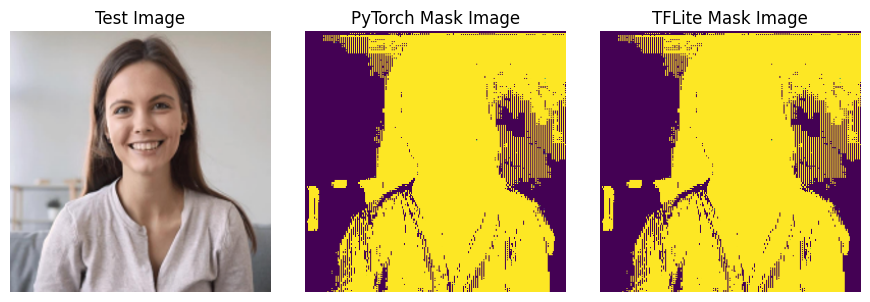

In [38]:
# Show output results

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

for idx, (title, image) in enumerate([
    ('Test Image', pil_image),
    ('PyTorch Mask Image', torch_mask_image),
    ('TFLite Mask Image', mask_image),
]):
  axes[idx].imshow(image)
  axes[idx].set_title(title)
  axes[idx].axis('off')

plt.tight_layout()
plt.show()


### Exporting Models for Google Play On-Device AI (PODAI)

With your models verified, the next essential step is preparing them for deployment. This section details how to package your compiled models for upload to Google Play, enabling delivery to user devices through the On-Demand AI (PODAI) framework.

The AiEdgeLiteRT AOT (Ahead-of-Time) module provides `ai_pack` utilities specifically for this purpose. These utilities create an **AI Pack**, which is a crucial data asset. An AI Pack bundles your compiled models with device-targeting configurations, ensuring that the correct models and assets are delivered to the appropriate user devices. This is particularly vital for NPU (Neural Processing Unit) compilations, as it guarantees that models optimized for a specific System-on-Chip (SoC) reach only the devices equipped with that SoC.

In [39]:
# Configuring the AI Pack
ai_pack_dir = os.path.join(work_dir, 'ai_pack')
ai_pack_name = 'selfie_segmentation'
litert_model_name = 'segmentation_model'

# Clean up
shutil.rmtree(ai_pack_dir, ignore_errors=True)

# Export
ai_pack_export.export(
    compiled_models, ai_pack_dir, ai_pack_name, litert_model_name
)

unsupported target  IntelOpenVINO_LNL
unsupported target  IntelOpenVINO_PTL


And now the models are ready for comsuption by PODAI!

Now we will move on to Android Studio for the following steps, please refer to [this documentation](https://github.com/google-ai-edge/litert-samples/tree/main/v2/image_segmentation/kotlin_npu) for details.

But if you are curious on the contents of AI Pack, we can take a look into the directory.

In [40]:
# @title Inspecting AI Pack source


def list_files(startpath):
  """Function to print out the tree structure of a directory."""
  for root, dirs, files in os.walk(startpath):
    level = root.replace(startpath, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print('{}{}/'.format(indent, os.path.basename(root)))
    subindent = ' ' * 4 * (level + 1)
    for f in files:
      print('{}{}'.format(subindent, f))


list_files(ai_pack_dir)

ai_pack/
    device_targeting_configuration.xml
    selfie_segmentation/
        src/
            main/
                assets/
                    model#group_Mediatek_MT6991/
                        segmentation_model.tflite
                    model#group_Google_Tensor_G3/
                        segmentation_model.tflite
                    model#group_IntelOpenVINO_PTL/
                        segmentation_model.tflite
                    model#group_Mediatek_MT6878/
                        segmentation_model.tflite
                    model#group_IntelOpenVINO_LNL/
                        segmentation_model.tflite
                    model#group_Mediatek_MT6983/
                        segmentation_model.tflite
                    model#group_Mediatek_MT6989/
                        segmentation_model.tflite
                    model#group_Mediatek_MT6993/
                        segmentation_model.tflite
                    model#group_Google_Tensor_G4/
                        s

## Advanced Usage

This section covers advanced usages like compiling a LiteRT (TFLite) model directly.


### NPU Compilation from TFLite model

In many of the cases, you might already have a TFLite converted models, which was published before, but the source model is not yet available or the source model is not a PyTorch model. In this case, instead of litert-torch package, you can use the APIs provided by ai-edge-litert compiler directly.

#### Getting the TFLite Model

We will use [MediaPipe MultiClass Segmentation](https://storage.googleapis.com/mediapipe-assets/Model%20Card%20Multiclass%20Segmentation.pdf) model for this use case.

The TFLite model is available from [MediaPipe Image segmentation](https://ai.google.dev/edge/mediapipe/solutions/vision/image_segmenter#multiclass-model) page.


In [41]:
work_dir = '.'

model_url = 'https://storage.googleapis.com/mediapipe-models/image_segmenter/selfie_multiclass_256x256/float32/latest/selfie_multiclass_256x256.tflite'
tflite_model_path = os.path.join(work_dir, 'selfie_multiclass_256x256.tflite')

model_content = requests.get(model_url)

with open(tflite_model_path, 'wb') as fout:
  fout.write(model_content.content)

#### Using LiteRT Python API to quickly verify the TfLite model

In the following example, we will show both mask image and blended result.

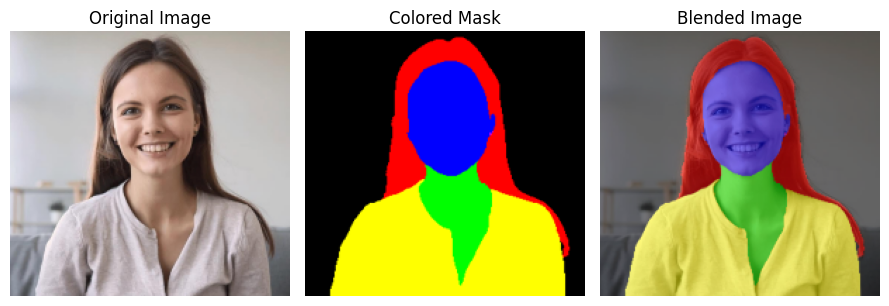

In [42]:
from ai_edge_litert.compiled_model import CompiledModel

SEGMENT_COLORS = [
    (0, 0, 0),
    (255, 0, 0),
    (0, 255, 0),
    (0, 0, 255),
    (255, 255, 0),
    (255, 0, 255),
]
INPUT_SIZE = (256, 256)
NUM_CLASSES = 6

# Load the model and image
model = CompiledModel.from_file(tflite_model_path)
original_image = np.array(Image.open(test_image).convert('RGB'))
img_array = np.array(pil_image).astype(np.float32)

# Normalize the image
normalized = (img_array - 127.5) / 127.5
normalized = np.ascontiguousarray(normalized, dtype=np.float32)

# Run inference
sig_idx = 0
input_buffers = model.create_input_buffers(sig_idx)
output_buffers = model.create_output_buffers(sig_idx)
input_data = normalized.reshape(-1)
input_buffers[0].write(input_data)
model.run_by_index(sig_idx, input_buffers, output_buffers)

# Get output data
height, width = INPUT_SIZE
output_size = height * width * NUM_CLASSES
output_data = output_buffers[0].read(output_size, np.float32)
output_data = output_data.reshape(height, width, NUM_CLASSES)
mask = np.argmax(output_data, axis=2).astype(np.uint8)

# Create colored mask
colored_mask = np.zeros((height, width, 3), dtype=np.uint8)
for label_idx in range(NUM_CLASSES):
  class_mask = mask == label_idx
  color = SEGMENT_COLORS[label_idx]
  colored_mask[class_mask] = color

# Blend with original image
# Resize colored mask to match original image if necessary
if original_image.shape[:2] != colored_mask.shape[:2]:
  colored_mask_pil = Image.fromarray(colored_mask)
  colored_mask_pil = colored_mask_pil.resize(
      (original_image.shape[1], original_image.shape[0])
  )
  colored_mask = np.array(colored_mask_pil)

# Blend images with alpha 0.5
alpha = 0.5
blended_image = (original_image * (1 - alpha) + colored_mask * alpha).astype(
    np.uint8
)

# Display them
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

for idx, (title, image) in enumerate([
    ('Original Image', original_image),
    ('Colored Mask', colored_mask),
    ('Blended Image', blended_image),
]):
  axes[idx].imshow(image)
  axes[idx].set_title(title)
  axes[idx].axis('off')

plt.tight_layout()
plt.show()

#### Convert to LiteRT model, with NPU AOT compilation.

Since it's a TFLite model, we will use `ai_edge_litert.aot` module instead of litert-torch APIs.

In [43]:
compiled_models = aot_lib.aot_compile(tflite_model_path, keep_going=True)

Backend:   0%|          | 0/34 [00:00<?, ?it/s]

Skipping failed compilation for MediaTek_MT6853. Error: apply_plugin failed to apply plugin. See /tmp/tmp4_3bugx3.error for details.
Skipping failed compilation for MediaTek_MT6886. Error: apply_plugin failed to apply plugin. See /tmp/tmp0_g5fxj1.error for details.
Skipping failed compilation for MediaTek_MT6895. Error: apply_plugin failed to apply plugin. See /tmp/tmpykr5enaa.error for details.
Skipping failed compilation for Qualcomm_SA8255. Error: apply_plugin failed to apply plugin. See /tmp/tmpz4odie87.error for details.
Skipping failed compilation for Qualcomm_SA8295. Error: apply_plugin failed to apply plugin. See /tmp/tmpbyz2yn5c.error for details.
Skipping failed compilation for Qualcomm_SM8350. Error: apply_plugin failed to apply plugin. See /tmp/tmp62cir9j1.error for details.
Skipping failed compilation for Qualcomm_SM8450. Error: apply_plugin failed to apply plugin. See /tmp/tmp7fq9ptna.error for details.
Skipping failed compilation for Qualcomm_SM8475. Error: apply_plugin 

For the following steps, it's the same as models compiled from PyTorch. e.g. For exporting for AI Pack

In [44]:
# Configuring the AI Pack
os.makedirs('selfie_multiclass',exist_ok=True)
ai_pack_dir = os.path.join('selfie_multiclass', 'ai_pack')
ai_pack_name = 'selfie_multiclass'
litert_model_name = 'segmentation_multiclass'

# Clean up
shutil.rmtree(ai_pack_dir, ignore_errors=True)

# Export
ai_pack_export.export(
    compiled_models, ai_pack_dir, ai_pack_name, litert_model_name
)

unsupported target  IntelOpenVINO_LNL
unsupported target  IntelOpenVINO_PTL


In [45]:
list_files(ai_pack_dir)

ai_pack/
    device_targeting_configuration.xml
    selfie_multiclass/
        src/
            main/
                assets/
                    model#group_Mediatek_MT6991/
                        segmentation_multiclass.tflite
                    model#group_Google_Tensor_G3/
                        segmentation_multiclass.tflite
                    model#group_Mediatek_MT6893/
                        segmentation_multiclass.tflite
                    model#group_IntelOpenVINO_PTL/
                        segmentation_multiclass.tflite
                    model#group_Mediatek_MT6878/
                        segmentation_multiclass.tflite
                    model#group_IntelOpenVINO_LNL/
                        segmentation_multiclass.tflite
                    model#group_Mediatek_MT6983/
                        segmentation_multiclass.tflite
                    model#group_Mediatek_MT6989/
                        segmentation_multiclass.tflite
                    model#group_Media

### NPU Compilation for specific device / NPU

By default, LiteRT AOT compilation compiles to all registered backends. But for local developement, you might only want to compile for specific devices, say the development phones by hand. This is achievable by providing the compilation targets explicitly.

The following example will compile to QualComm SM8450 SoC , Samsung Exynos2600 SoC and MediaTek MT6989 SoC.

In [46]:
# @title Specifying the compilation target

sm8450_target = qnn_target.Target(qnn_target.SocModel.SM8450)
mt6989_target = mtk_target.Target(mtk_target.SocModel.MT6989)
e9965_target  = enn_target.Target(enn_target.SocModel.E9965)

In [47]:
# @title Compiling from PyTorch model

compiled_models = (
    litert_torch.experimental_add_compilation_backend(sm8450_target)
    .experimental_add_compilation_backend(mt6989_target)
    .experimental_add_compilation_backend(e9965_target)
    .convert(channel_last_selfie_segmentation, sample_input)
)

(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


(00:02) [ DONE] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions (+00:01)

...

(00:14) [ DONE] LiteRT-Torch Convert (+00:14)

(00:00) [START] Write Model to Bytes

(00:00) [ DONE] Write Model to Bytes (+00:00)

Backend:   0%|          | 0/3 [00:00<?, ?it/s]

Skipping failed compilation for Qualcomm_SM8450. Error: apply_plugin failed to apply plugin. See /tmp/tmpaa4zj88f.error for details.
Skipping failed compilation for Samsung_E9965. Error: apply_plugin failed to apply plugin. See /tmp/tmpwyin_k_q.error for details.


In [48]:
# @title Compiling from TFLite model

compiled_models = aot_lib.aot_compile(
    tflite_model_path,
    target=[sm8450_target, mt6989_target, e9965_target],
    keep_going=False,  # We want to error out when there's failure.
)

Backend:   0%|          | 0/3 [00:00<?, ?it/s]

ValueError: apply_plugin failed to apply plugin. See /tmp/tmp3n_a2mfu.error for details.